<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp%203%20new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 SMART HOSPITAL LIVE PATIENT MONITORING 
Patients Processed : 6/25
Monitoring Time    : 25 sec



,Patient,Blood Pressure (mmHg),Respiratory Rate (breaths/min),Blood Glucose (mg/dL),Status
0,P01,162/108,10,187,EMERGENCY
1,P02,101/70,11,143,EMERGENCY
2,P03,178/107,13,180,EMERGENCY
3,P04,110/87,11,131,EMERGENCY
4,P05,113/67,17,102,NORMAL
5,P06,159/105,14,73,EMERGENCY



Normal Patients : 1
Emergency Patients : 5

🚨 EMERGENCY ALERT 🚨


,Patient,Blood Pressure (mmHg),Respiratory Rate (breaths/min),Blood Glucose (mg/dL),Status
0,P01,162/108,10,187,EMERGENCY
1,P02,101/70,11,143,EMERGENCY
2,P03,178/107,13,180,EMERGENCY
3,P04,110/87,11,131,EMERGENCY
5,P06,159/105,14,73,EMERGENCY


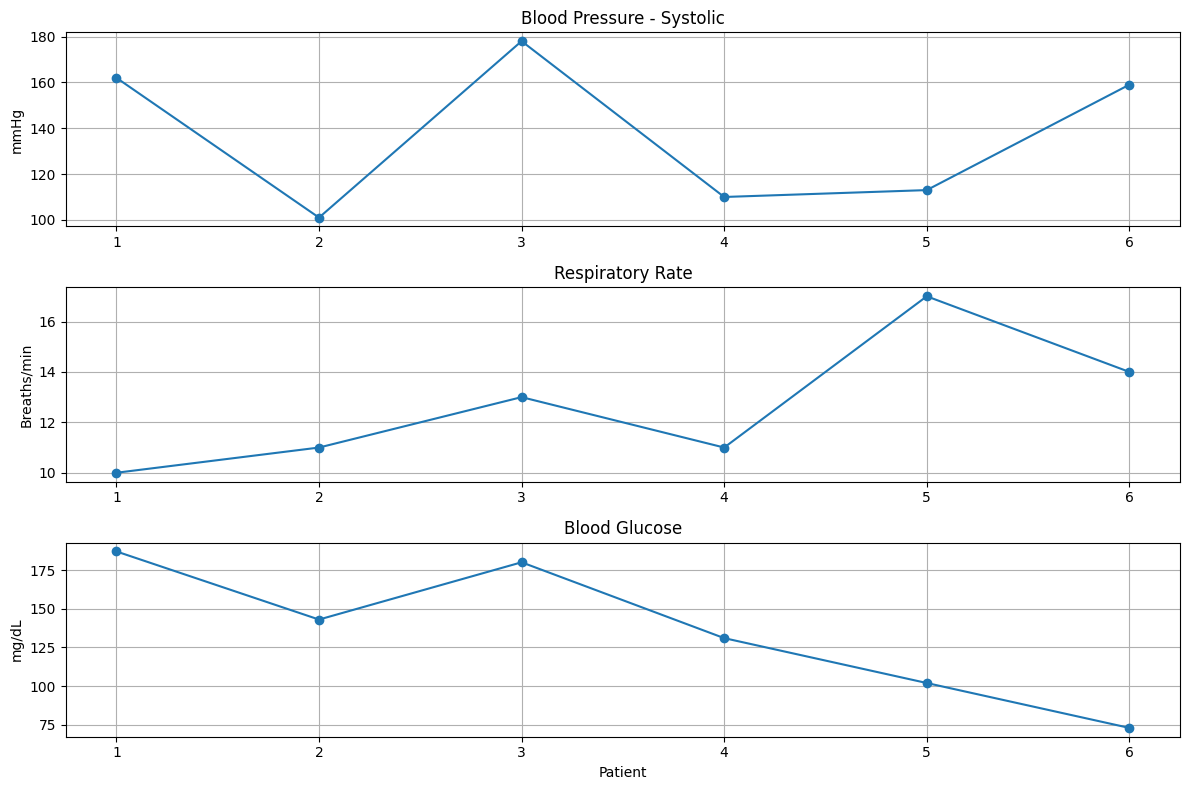

In [ ]:
# ==========================================================
# SMART HOSPITAL LIVE PATIENT MONITORING
# Parameters: Blood Pressure, Respiratory Rate, Blood Glucose
# Google Colab
# ==========================================================

import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------

TOTAL_PATIENTS = 25
UPDATE_INTERVAL = 5

patient_ids = []
blood_pressure = []
respiratory_rate = []
blood_glucose = []
status_list = []
time_axis = []

# ----------------------------------------------------------
# GENERATE PATIENT DATA
# ----------------------------------------------------------

def generate_patient():

    systolic = random.randint(90, 180)
    diastolic = random.randint(60, 110)
    respiration = random.randint(10, 30)
    glucose = random.randint(70, 200)

    # Emergency conditions
    if (systolic >= 140 or systolic < 90 or
        diastolic >= 90 or diastolic < 60 or
        respiration > 20 or respiration < 12 or
        glucose >= 180 or glucose < 70):

        status = "EMERGENCY"

    else:
        status = "NORMAL"

    bp = f"{systolic}/{diastolic}"

    return bp, systolic, diastolic, respiration, glucose, status


# ----------------------------------------------------------
# LIVE GRAPH
# ----------------------------------------------------------

def live_graph():

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(time_axis,
             [int(x.split('/')[0]) for x in blood_pressure],
             marker='o')
    plt.title("Blood Pressure - Systolic")
    plt.ylabel("mmHg")
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(time_axis, respiratory_rate, marker='o')
    plt.title("Respiratory Rate")
    plt.ylabel("Breaths/min")
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(time_axis, blood_glucose, marker='o')
    plt.title("Blood Glucose")
    plt.xlabel("Patient")
    plt.ylabel("mg/dL")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ==========================================================
# LIVE MONITORING LOOP
# ==========================================================

for patient in range(1, TOTAL_PATIENTS + 1):

    # Generate patient data
    bp, systolic, diastolic, respiration, glucose, status = generate_patient()

    # Store values
    patient_ids.append(f"P{patient:02d}")
    blood_pressure.append(bp)
    respiratory_rate.append(respiration)
    blood_glucose.append(glucose)
    status_list.append(status)
    time_axis.append(patient)

    # Create DataFrame
    df = pd.DataFrame({
        "Patient": patient_ids,
        "Blood Pressure (mmHg)": blood_pressure,
        "Respiratory Rate (breaths/min)": respiratory_rate,
        "Blood Glucose (mg/dL)": blood_glucose,
        "Status": status_list
    })

    # Clear previous output
    clear_output(wait=True)

    print("=" * 80)
    print(" SMART HOSPITAL LIVE PATIENT MONITORING ")
    print("=" * 80)

    print(f"Patients Processed : {patient}/{TOTAL_PATIENTS}")
    print(f"Monitoring Time    : {(patient-1) * UPDATE_INTERVAL} sec")
    print()

    # Display live table
    display(df)

    # Emergency patients
    emergency = df[df["Status"] == "EMERGENCY"]

    print("\nNormal Patients :", len(df) - len(emergency))
    print("Emergency Patients :", len(emergency))

    if len(emergency) > 0:
        print("\n🚨 EMERGENCY ALERT 🚨")
        display(emergency)

    # Live graphs
    live_graph()

    # Wait before next patient
    if patient != TOTAL_PATIENTS:
        time.sleep(UPDATE_INTERVAL)

print("\nMonitoring Completed Successfully!")